<a href="https://colab.research.google.com/github/will001-art-ke/WILL/blob/main/mnist_dataset_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**TRAINING ML MODEL USING TENSOR FLOW**
Import TensorFlow

Load and prepare the MNIST dataset. The pixel values of the images range from 0 through 255. Scale these values to a range of 0 to 1 by dividing the values by 255.0

Build a tf.keras.Sequential model

use either softmax or relu as your activation functions.

define the loss function.

configure and compile the model using Keras Model.compile. Set the optimizer class to adam, set the loss to the loss_fn function you defined earlier, and specify a metric to be evaluated for the model by setting the metrics

Train and evaluate your model

Use the Model.fit method to adjust your model parameters and minimize the loss.

check the model's performance.



In [4]:
import tensorflow as tf

# Load the MNIST dataset
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Dataset loaded successfully.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully.


In [5]:
# Normalize the pixel values to a range of 0 to 1
x_train, x_test = x_train / 255.0, x_test / 255.0

# Build the tf.keras.Sequential model using the recommended Input layer
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Define the loss function
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False)

# Configure and compile the model
model.compile(optimizer='adam',
              loss=loss_fn,
              metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=10)

# Check the model's performance
model.evaluate(x_test,  y_test, verbose=2)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9134 - loss: 0.2972
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9567 - loss: 0.1443
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9677 - loss: 0.1065
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9727 - loss: 0.0872
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9763 - loss: 0.0763
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9785 - loss: 0.0686
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9804 - loss: 0.0601
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9828 - loss: 0.0526
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9837 - loss: 0.0489
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9843 - loss: 0.0463
313/313 - 1s - 2ms/step - accuracy: 0.9779 - loss: 0.0721


[0.07206413894891739, 0.9779000282287598]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


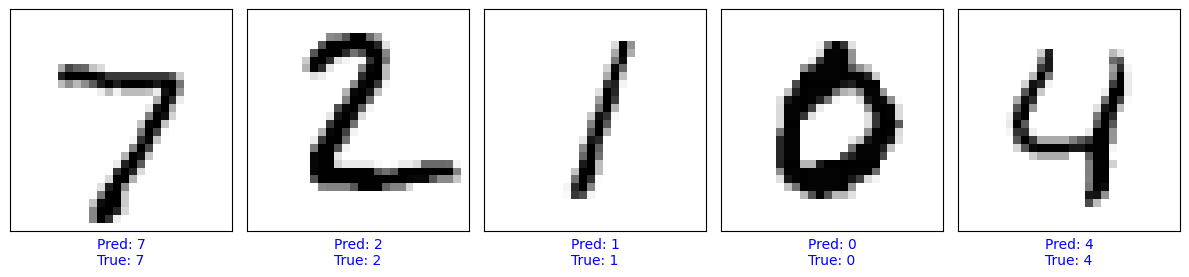

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

# Helper to ensure data and model are available
try:
    # Check if model exists, if not, this will trigger the NameError
    _ = model

    # Make predictions
    predictions = model.predict(x_test)

    # Visualize the first 5 test images
    plt.figure(figsize=(12, 4))
    for i in range(5):
        plt.subplot(1, 5, i+1)
        plt.xticks([])
        plt.yticks([])
        plt.grid(False)
        plt.imshow(x_test[i], cmap=plt.cm.binary)

        predicted_label = np.argmax(predictions[i])
        true_label = y_test[i]

        color = 'blue' if predicted_label == true_label else 'red'
        plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.tight_layout()
    plt.show()
except NameError:
    print("The 'model' or 'x_test' variables are not defined. Please run the cells above (Nk5S_RW-EZ90 and 526dd00a) to load data and train the model.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Total misclassified images: 221 out of 10000


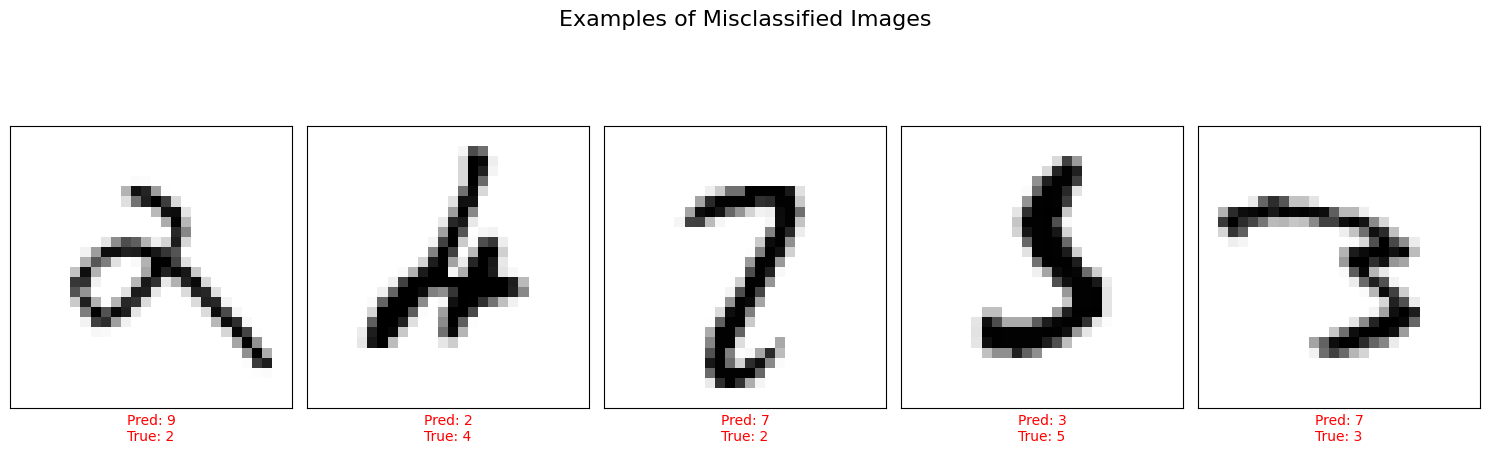

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Get the class predictions for the entire test set
test_predictions = model.predict(x_test)
test_predicted_labels = np.argmax(test_predictions, axis=1)

# Find indices where predictions do not match true labels
misclassified_indices = np.where(test_predicted_labels != y_test)[0]

print(f"Total misclassified images: {len(misclassified_indices)} out of {len(y_test)}")

# Visualize the first 5 misclassified images
plt.figure(figsize=(15, 5))
for i, bad_idx in enumerate(misclassified_indices[:5]):
    plt.subplot(1, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_test[bad_idx], cmap=plt.cm.binary)

    plt.xlabel(f"Pred: {test_predicted_labels[bad_idx]}\nTrue: {y_test[bad_idx]}", color='red')

plt.suptitle("Examples of Misclassified Images", fontsize=16)
plt.tight_layout()
plt.show()

### Search for Specific Test Images
Use the cell below to look up a specific image by its index in the test set.

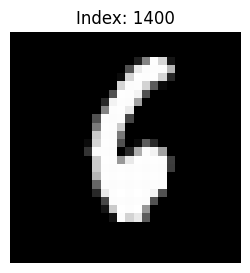

In [11]:
search_index = 1400 # @param {type:"integer"}

if 0 <= search_index < len(x_test):
    img = x_test[search_index]
    true_label = y_test[search_index]

    # Get prediction
    pred_probs = model.predict(img.reshape(1, 28, 28), verbose=0)
    predicted_label = np.argmax(pred_probs)

    plt.figure(figsize=(3, 3))
    plt.imshow(img, cmap='gray')
    plt.title(f"Index: {search_index}")
    color = 'blue' if predicted_label == true_label else 'red'
    plt.xlabel(f"Pred: {predicted_label}\nTrue: {true_label}", color=color)
    plt.axis('off')
    plt.show()
else:
    print(f"Invalid index. Please enter a value between 0 and {len(x_test)-1}.")

In [12]:
import pandas as pd

# Calculate accuracy for each digit class
class_accuracies = {}

for digit in range(10):
    # Filter indices for the current digit
    indices = np.where(y_test == digit)[0]

    # Calculate accuracy for these indices
    correct_predictions = np.sum(test_predicted_labels[indices] == y_test[indices])
    accuracy = correct_predictions / len(indices)
    class_accuracies[digit] = accuracy

# Display the results as a table
accuracy_df = pd.DataFrame(list(class_accuracies.items()), columns=['Digit', 'Accuracy'])
accuracy_df['Accuracy'] = accuracy_df['Accuracy'].map('{:.2%}'.format)
display(accuracy_df)

,Digit,Accuracy
0,0,98.88%
1,1,98.94%
2,2,97.77%
3,3,98.12%
4,4,97.66%
5,5,97.42%
6,6,98.64%
7,7,97.57%
8,8,96.20%
9,9,96.53%


In [13]:
print(f"Training images shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test images shape: {x_test.shape}")
print(f"Test labels shape: {y_test.shape}")

# Also displaying the number of unique classes
unique_classes = np.unique(y_train)
print(f"Number of classes: {len(unique_classes)} ({unique_classes})")

Training images shape: (60000, 28, 28)
Training labels shape: (60000,)
Test images shape: (10000, 28, 28)
Test labels shape: (10000,)
Number of classes: 10 ([0 1 2 3 4 5 6 7 8 9])


## Model Performance Summary Report
This report summarizes the evaluation results for the MNIST digit classification model.

In [14]:
results = model.evaluate(x_test, y_test, verbose=0)
overall_loss = results[0]
overall_accuracy = results[1]

# Identify best and worst performing digits
# Using the accuracy_df created in previous steps
sorted_acc = accuracy_df.sort_values(by='Accuracy', ascending=False)
best_digit = sorted_acc.iloc[0]['Digit']
best_acc = sorted_acc.iloc[0]['Accuracy']
worst_digit = sorted_acc.iloc[-1]['Digit']
worst_acc = sorted_acc.iloc[-1]['Accuracy']

print("--- GLOBAL METRICS ---")
print(f"Overall Test Accuracy: {overall_accuracy:.2%}")
print(f"Overall Test Loss:     {overall_loss:.4f}")
print("\n--- CLASS INSIGHTS ---")
print(f"Highest Accuracy: Digit {best_digit} ({best_acc})")
print(f"Lowest Accuracy:  Digit {worst_digit} ({worst_acc})")
print("\n--- RECOMMENDATIONS ---")
if overall_accuracy > 0.97:
    print("Performance is excellent. To improve further, consider data augmentation or a Convolutional Neural Network (CNN).")
else:
    print("Consider increasing epochs or adding more neurons to the hidden layer.")

--- GLOBAL METRICS ---
Overall Test Accuracy: 97.79%
Overall Test Loss:     0.0721

--- CLASS INSIGHTS ---
Highest Accuracy: Digit 1 (98.94%)
Lowest Accuracy:  Digit 8 (96.20%)

--- RECOMMENDATIONS ---
Performance is excellent. To improve further, consider data augmentation or a Convolutional Neural Network (CNN).


### CNN Implementation
To use a CNN, we need to reshape our data to include a channel dimension (28x28x1).

In [15]:
# Reshape data for CNN (batch, height, width, channels)
x_train_cnn = x_train.reshape(-1, 28, 28, 1)
x_test_cnn = x_test.reshape(-1, 28, 28, 1)

# Build CNN model
cnn_model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile
cnn_model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
print("Training CNN model...")
cnn_model.fit(x_train_cnn, y_train, epochs=5)

# Evaluate
print("\nEvaluating CNN model:")
cnn_model.evaluate(x_test_cnn, y_test, verbose=2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training CNN model...
Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9568 - loss: 0.1406
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9852 - loss: 0.0479
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 25ms/step - accuracy: 0.9899 - loss: 0.0330
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9931 - loss: 0.0228
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 46s 25ms/step - accuracy: 0.9944 - loss: 0.0179

Evaluating CNN model:
313/313 - 3s - 8ms/step - accuracy: 0.9899 - loss: 0.0351


[0.035062070935964584, 0.9898999929428101]

### CNN vs. Dense Model: Per-Digit Accuracy Comparison
We will now calculate the accuracy for each digit using the CNN model and compare it with our previous results.

In [16]:
# Get CNN predictions
cnn_probs = cnn_model.predict(x_test_cnn)
cnn_preds = np.argmax(cnn_probs, axis=1)

cnn_class_accuracies = {}
for digit in range(10):
    indices = np.where(y_test == digit)[0]
    correct = np.sum(cnn_preds[indices] == y_test[indices])
    cnn_class_accuracies[digit] = correct / len(indices)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Digit': range(10),
    'Dense Accuracy (%)': [accuracy_df.loc[accuracy_df['Digit'] == d, 'Accuracy'].values[0].replace('%','') for d in range(10)],
    'CNN Accuracy (%)': [f"{cnn_class_accuracies[d]*100:.2f}" for d in range(10)]
})

# Convert to float for calculation
comparison_df['Dense Accuracy (%)'] = comparison_df['Dense Accuracy (%)'].astype(float)
comparison_df['CNN Accuracy (%)'] = comparison_df['CNN Accuracy (%)'].astype(float)
comparison_df['Improvement (%)'] = comparison_df['CNN Accuracy (%)'] - comparison_df['Dense Accuracy (%)']

display(comparison_df.style.highlight_max(subset=['Dense Accuracy (%)', 'CNN Accuracy (%)'], color='lightgreen', axis=1))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


,Digit,Dense Accuracy (%),CNN Accuracy (%),Improvement (%)
0,0,98.880000,99.080000,0.200000
1,1,98.940000,99.740000,0.800000
2,2,97.770000,99.520000,1.750000
3,3,98.120000,99.010000,0.890000
4,4,97.660000,99.690000,2.030000
5,5,97.420000,98.990000,1.570000
6,6,98.640000,99.370000,0.730000
7,7,97.570000,97.670000,0.100000
8,8,96.200000,98.670000,2.470000
9,9,96.530000,98.120000,1.590000


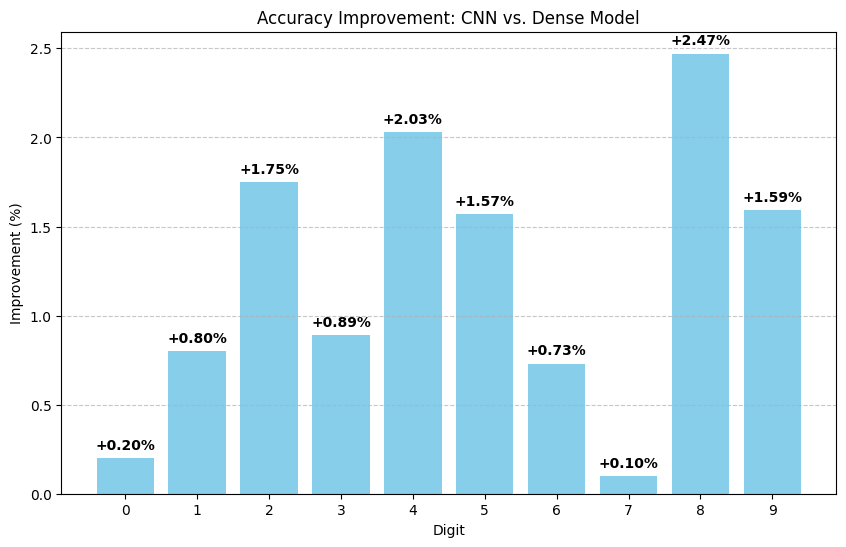

In [17]:
import matplotlib.pyplot as plt

# Plotting the Improvement (%)
plt.figure(figsize=(10, 6))
plt.bar(comparison_df['Digit'], comparison_df['Improvement (%)'], color='skyblue')
plt.xlabel('Digit')
plt.ylabel('Improvement (%)')
plt.title('Accuracy Improvement: CNN vs. Dense Model')
plt.xticks(range(10))
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adding text labels on top of the bars
for i, val in enumerate(comparison_df['Improvement (%)']):
    plt.text(i, val + 0.05, f'+{val:.2f}%', ha='center', fontweight='bold')

plt.show()